# 📊 Modelos de Clasificación en Machine Learning

---

## ¿Qué es la clasificación?

La **clasificación** es una tarea de Machine Learning donde el objetivo es **asignar una etiqueta o categoría** a una observación, basándose en sus características.

**Ejemplos reales:**
- ¿Este correo es spam o no spam?
- ¿Esta imagen es un gato, un perro o un pájaro?
- ¿Esta flor es de la especie Setosa, Versicolor o Virginica?

En este notebook exploraremos **8 algoritmos de clasificación** distintos, los aplicaremos sobre el mismo dataset y compararemos sus resultados.

---

## 🌸 Dataset: Iris

El dataset **Iris** es uno de los más usados en Machine Learning para aprender y comparar modelos. Contiene:

| Característica | Descripción |
|---|---|
| `sepal length` | Longitud del sépalo (cm) |
| `sepal width` | Ancho del sépalo (cm) |
| `petal length` | Longitud del pétalo (cm) |
| `petal width` | Ancho del pétalo (cm) |
| `species` | Especie de la flor (0=Setosa, 1=Versicolor, 2=Virginica) |

🎯 **Objetivo:** Predecir la especie de una flor a partir de sus medidas.


## 📦 1. Importación de librerías

Antes de empezar, cargamos todas las herramientas que vamos a necesitar:

- **numpy / pandas**: Para manejo de datos y matrices.
- **matplotlib**: Para crear gráficos y visualizaciones.
- **sklearn**: La librería principal de Machine Learning en Python. Contiene los modelos, métricas y utilidades.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

## 🌸 2. Cargar y explorar el Dataset

Cargamos el dataset Iris directamente desde `sklearn`. Luego lo convertimos en un DataFrame de pandas para verlo de forma más cómoda.

Las primeras filas nos muestran cómo están estructurados los datos: cada fila es una flor, y cada columna es una medida de esa flor.

In [2]:
iris = load_iris()

X = iris.data   # Características (features): las medidas de la flor
y = iris.target  # Etiqueta (label): la especie (0, 1 o 2)

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 📈 3. Visualización de los datos

Antes de entrenar cualquier modelo, siempre conviene **visualizar los datos**. Esto nos ayuda a entender si las clases son separables y qué tan difícil podría ser el problema.

Graficamos **longitud del pétalo vs. ancho del pétalo** coloreando cada flor según su especie.

### 🔍 ¿Cómo interpretar esta gráfica?
- Cada **punto** representa una flor del dataset.
- El **color** indica la especie: morado = Setosa, verde = Versicolor, amarillo = Virginica.
- Si los colores forman **grupos bien separados**, significa que las características son buenas para distinguir las especies → los modelos tendrán más facilidad para clasificar.
- En este caso verás que **Setosa está claramente separada**, mientras que Versicolor y Virginica se solapan un poco.

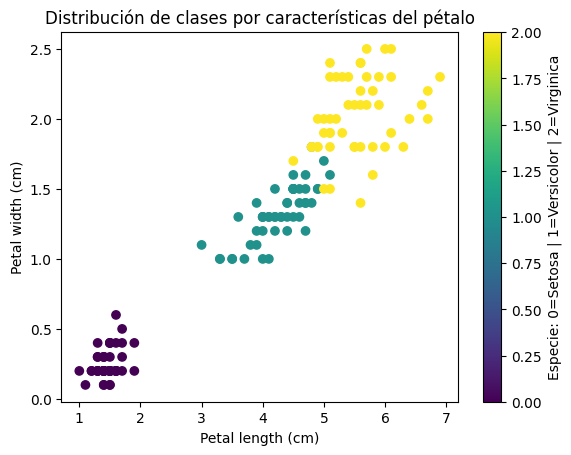

In [3]:
plt.figure()
plt.scatter(X[:,2], X[:,3], c=y, cmap='viridis')
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Distribución de clases por características del pétalo")
plt.colorbar(label='Especie: 0=Setosa | 1=Versicolor | 2=Virginica')
plt.show()

## ✂️ 4. División del dataset y escalado

### División Train / Test
Dividimos el dataset en dos partes:
- **Entrenamiento (80%)**: el modelo aprende con estos datos.
- **Test (20%)**: evaluamos si el modelo aprendió bien con datos que **nunca ha visto**.

Esto simula lo que pasaría en la vida real: entrenamos con datos históricos y predecimos datos nuevos.

### Escalado (StandardScaler)
Algunos modelos (como SVM, KNN o Redes Neuronales) son sensibles a la **escala de los datos**. Si una característica tiene valores entre 0 y 1, y otra entre 0 y 1000, el modelo podría darse por sesgado hacia la segunda.

El escalado transforma cada característica para que tenga **media 0 y desviación estándar 1**, igualando su importancia.

> ⚠️ **Importante:** El scaler se entrena **solo con los datos de entrenamiento** (`fit_transform`). Luego se aplica a los datos de test (`transform`) sin re-entrenar, para evitar filtración de información.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Aprende la escala y transforma
X_test_sc = scaler.transform(X_test)        # Solo transforma (sin aprender)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de test:          {X_test.shape[0]} muestras")

Datos de entrenamiento: 120 muestras
Datos de test:          30 muestras


## 📐 ¿Cómo evaluar un modelo de clasificación?

Usamos dos herramientas principales:

### 1. Accuracy (Exactitud)
Porcentaje de predicciones correctas sobre el total:
```
Accuracy = Predicciones correctas / Total de predicciones
```
Un **Accuracy de 1.0 = 100%** de aciertos. Un valor de 0.95 = 95% de aciertos.

### 2. Matriz de Confusión
Una tabla que muestra **cuántas flores fueron clasificadas correctamente y cuáles se confundieron**:

```
               Predicho
             Setosa | Versicolor | Virginica
Real Setosa  [  10  |     0      |    0    ]
Real Versi   [   0  |     9      |    1    ]
Real Virgin  [   0  |     0      |   10    ]
```
- Los valores en la **diagonal principal** son los **aciertos** (predicho correcto).
- Los valores **fuera de la diagonal** son los **errores** (por ejemplo, predijo Versicolor cuando era Virginica).

In [5]:
# Diccionario para guardar los resultados de cada modelo
resultados = {}

---
# 🤖 Entrenamiento de Modelos
---

## Modelo 1: Regresión Logística

### ¿Qué hace?
A pesar del nombre, es un **modelo de clasificación**. Calcula la **probabilidad** de que una muestra pertenezca a cada clase y asigna la clase con mayor probabilidad.

Internamente traza una **frontera lineal** (una línea o plano) que separa las clases en el espacio de características.

### ¿Cuándo usarlo?
- Cuando el problema es relativamente **simple y lineal**.
- Cuando necesitas **interpretar** los resultados fácilmente.
- Como **baseline** o punto de partida para comparar otros modelos.

### Sobre el código
- `max_iter=500`: Le damos suficientes iteraciones para que el modelo converja (encuentre la mejor solución).
- Usa los datos **escalados** (`X_train_sc`) porque es sensible a la escala.

✅ Accuracy: 100.00%


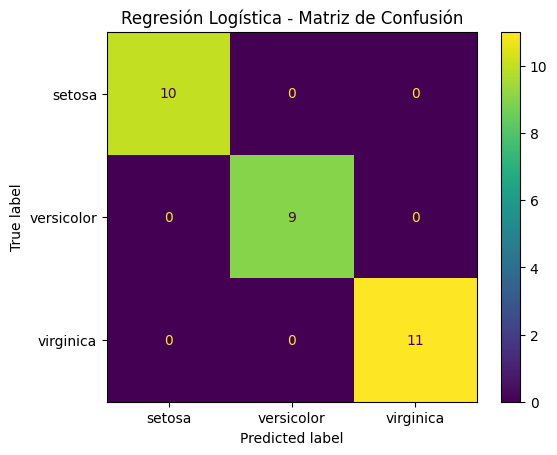

In [6]:
modelo = LogisticRegression(max_iter=500)
modelo.fit(X_train_sc, y_train)       # Entrenamiento
pred = modelo.predict(X_test_sc)      # Predicción sobre datos de test

acc = accuracy_score(y_test, pred)
resultados["Regresión Logística"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("Regresión Logística - Matriz de Confusión")
plt.show()

---
## Modelo 2: Naive Bayes (Gaussiano)

### ¿Qué hace?
Aplica el **Teorema de Bayes** asumiendo que las características son **independientes entre sí** (de ahí el 'naive' = ingenuo). Para cada clase, calcula la probabilidad de que una muestra pertenezca a ella y elige la más alta.

La versión **Gaussiana** asume que los datos siguen una distribución normal (campana de Gauss).

### ¿Cuándo usarlo?
- Cuando tienes **muchos datos y pocas características**.
- Cuando necesitas un modelo **muy rápido** de entrenar.
- En clasificación de **texto** (aunque ahí se usa MultinomialNB).

### Sobre el código
- No necesita escalado porque trabaja con probabilidades sobre la distribución de cada característica.

✅ Accuracy: 100.00%


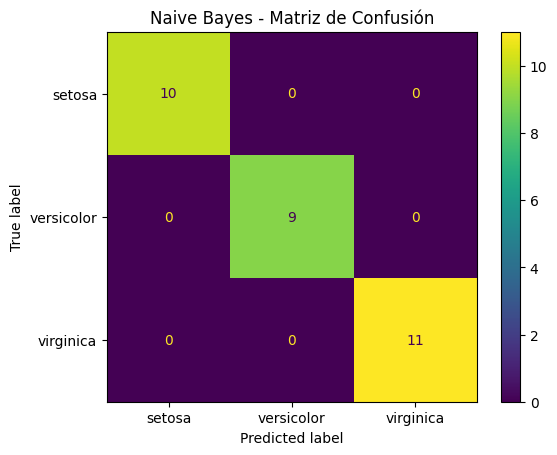

In [7]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

acc = accuracy_score(y_test, pred)
resultados["Naive Bayes"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("Naive Bayes - Matriz de Confusión")
plt.show()

---
## Modelo 3: Árbol de Decisión

### ¿Qué hace?
Construye un **árbol de preguntas** tipo "¿El pétalo mide más de 2.5 cm? → Sí → ¿El ancho es mayor a 1.8? → ...". En cada nodo hace una pregunta sobre una característica y divide los datos. Al final de cada rama, asigna una clase.

Es el modelo **más fácil de interpretar** visualmente: puedes exportar el árbol y leer las reglas exactas que usa.

### ¿Cuándo usarlo?
- Cuando necesitas **explicar** el razonamiento del modelo a personas no técnicas.
- Cuando quieres entender **qué variables son más importantes**.
- Prototipos rápidos.

### Sobre el código
- `max_depth=4`: Limitamos la profundidad del árbol para evitar **overfitting** (memorizar los datos de entrenamiento en lugar de aprender patrones generales).

✅ Accuracy: 100.00%


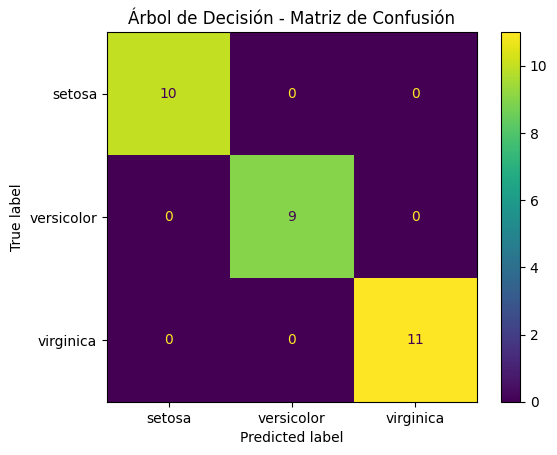

In [8]:
modelo = DecisionTreeClassifier(max_depth=4)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

acc = accuracy_score(y_test, pred)
resultados["Árbol de Decisión"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("Árbol de Decisión - Matriz de Confusión")
plt.show()

---
## Modelo 4: Random Forest

### ¿Qué hace?
Entrena **muchos árboles de decisión** en paralelo, cada uno con una muestra aleatoria de los datos y un subconjunto aleatorio de características. Al predecir, todos los árboles "votan" y gana la clase más votada.

> 💡 **Analogía:** Imagina que en lugar de pedirle consejo a una sola persona (un árbol), consultas a 100 expertos distintos y tomas la decisión por mayoría. Es mucho más robusto.

### ¿Cuándo usarlo?
- Cuando el dataset es **mediano o grande**.
- Cuando quieres un modelo **robusto y preciso** sin mucho ajuste de hiperparámetros.
- Uno de los modelos más usados en producción.

✅ Accuracy: 100.00%


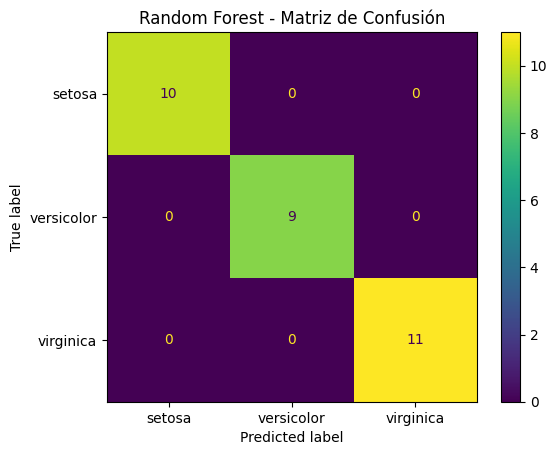

In [9]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

acc = accuracy_score(y_test, pred)
resultados["Random Forest"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("Random Forest - Matriz de Confusión")
plt.show()

---
## Modelo 5: Gradient Boosting

### ¿Qué hace?
También construye muchos árboles, pero de forma **secuencial**. Cada nuevo árbol aprende a **corregir los errores** del árbol anterior. Al final, combina todos los árboles ponderando sus contribuciones.

> 💡 **Analogía:** Es como un estudiante que revisa cada examen fallido para mejorar específicamente en lo que falló, en lugar de estudiar todo de nuevo desde cero.

### ¿Cuándo usarlo?
- Cuando necesitas la **máxima precisión** posible.
- En competiciones de Machine Learning (XGBoost/LightGBM son variantes muy populares).
- Puede ser más lento que Random Forest al entrenar.

✅ Accuracy: 100.00%


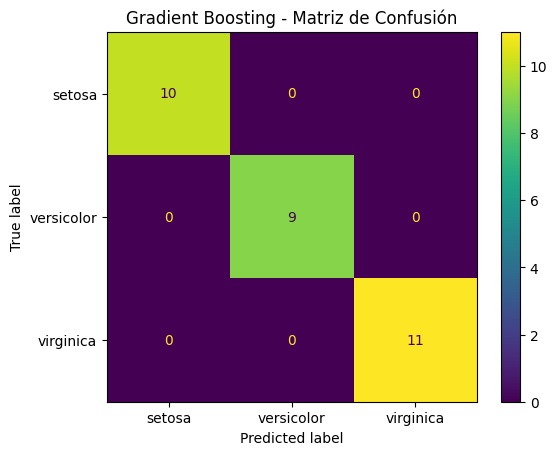

In [10]:
modelo = GradientBoostingClassifier(random_state=42)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

acc = accuracy_score(y_test, pred)
resultados["Gradient Boosting"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("Gradient Boosting - Matriz de Confusión")
plt.show()

---
## Modelo 6: KNN (K-Nearest Neighbors)

### ¿Qué hace?
Para clasificar un punto nuevo, busca los **K puntos más cercanos** en el espacio de características (sus vecinos más próximos) y asigna la clase más frecuente entre esos vecinos.

> 💡 **Analogía:** "Dime con quién andas y te diré quién eres." Si los 5 vecinos más cercanos a una flor son Versicolor, muy probablemente esa flor también es Versicolor.

### ¿Cuándo usarlo?
- Problemas pequeños o medianos.
- Cuando no necesitas interpretar el modelo (es una "caja negra" simple).
- ⚠️ **Requiere escalado**: La distancia entre puntos depende de la escala de las variables.

### Sobre el código
- Por defecto usa `n_neighbors=5`, es decir, busca los 5 vecinos más cercanos.

✅ Accuracy: 100.00%


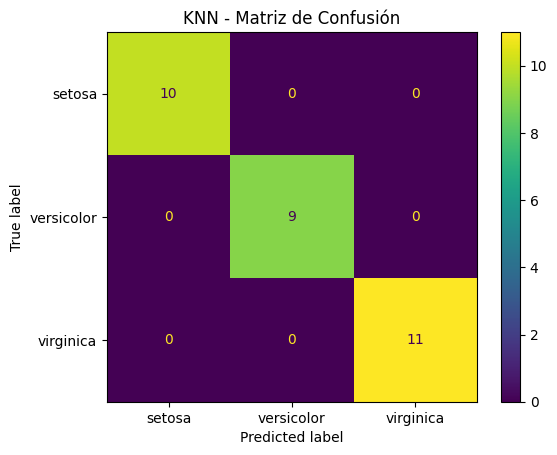

In [11]:
modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train_sc, y_train)
pred = modelo.predict(X_test_sc)

acc = accuracy_score(y_test, pred)
resultados["KNN"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("KNN - Matriz de Confusión")
plt.show()

---
## Modelo 7: SVM (Support Vector Machine)

### ¿Qué hace?
Busca el **hiperplano óptimo** que separa las clases con el **mayor margen posible**. Los puntos más cercanos a ese hiperplano se llaman "vectores de soporte" y son los que definen la frontera.

Con el truco del **kernel**, puede crear fronteras no lineales (curvas) en el espacio original, transformando los datos a un espacio de mayor dimensión donde sí son linealmente separables.

> 💡 **Analogía:** Imagina que quieres separar manzanas y naranjas sobre una mesa. Si están mezcladas, pones una tabla (hiperplano) lo más lejos posible de ambos grupos.

### ¿Cuándo usarlo?
- Datos con **pocas características** pero compleja separación.
- Cuando el dataset no es extremadamente grande.
- ⚠️ **Requiere escalado obligatoriamente**.

✅ Accuracy: 100.00%


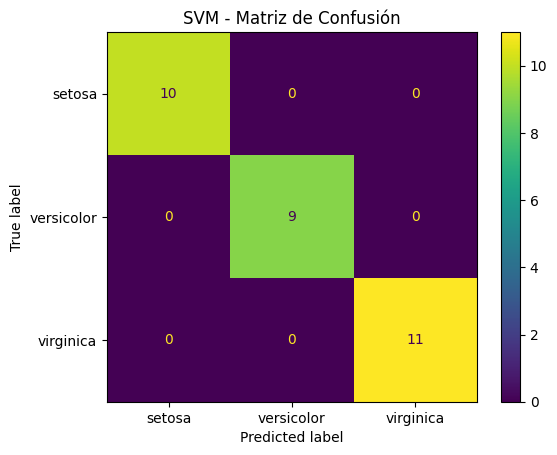

In [12]:
modelo = SVC(kernel='rbf')
modelo.fit(X_train_sc, y_train)
pred = modelo.predict(X_test_sc)

acc = accuracy_score(y_test, pred)
resultados["SVM"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("SVM - Matriz de Confusión")
plt.show()

---
## Modelo 8: Red Neuronal (MLP - MultiLayer Perceptron)

### ¿Qué hace?
Simula (de forma simplificada) el funcionamiento del cerebro humano. Está formada por **capas de neuronas artificiales** conectadas entre sí. Los datos entran por la capa de entrada, se procesan en capas ocultas y se obtiene la predicción en la capa de salida.

Cada conexión tiene un **peso** que se ajusta durante el entrenamiento (proceso llamado backpropagation) para minimizar el error.

### ¿Cuándo usarlo?
- Cuando otros modelos no logran capturar la complejidad del problema.
- Con datasets **grandes y complejos**.
- ⚠️ Requiere más datos, más tiempo de entrenamiento y escalado.
- Para imágenes, texto o audio se usan redes más especializadas (CNN, RNN, Transformers).

### Sobre el código
- `max_iter=2000`: Las redes neuronales necesitan más iteraciones para converger.

✅ Accuracy: 100.00%


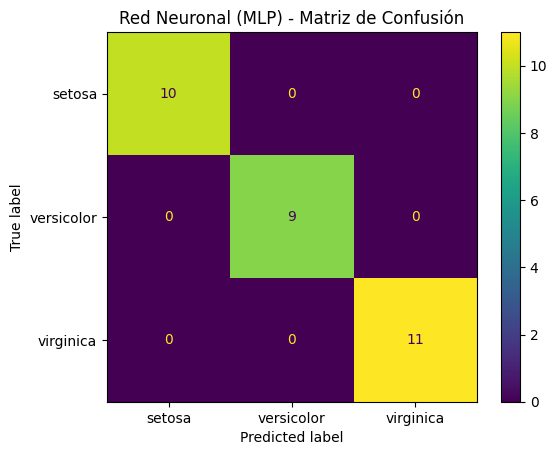

In [13]:
modelo = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42)
modelo.fit(X_train_sc, y_train)
pred = modelo.predict(X_test_sc)

acc = accuracy_score(y_test, pred)
resultados["Red Neuronal"] = acc

print(f"✅ Accuracy: {acc:.2%}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=iris.target_names)
plt.title("Red Neuronal (MLP) - Matriz de Confusión")
plt.show()

---
# 🏆 Comparación Final de Modelos

Mostramos el **accuracy de todos los modelos** en un gráfico de barras para comparar fácilmente cuál rindió mejor.

### 🔍 ¿Cómo interpretar el gráfico?
- El **eje Y** muestra el accuracy (0 = 0%, 1 = 100%).
- Cuanto **más alta** la barra, mejor clasifica ese modelo.
- Si todos tienen **accuracy = 1.0** (100%), significa que el dataset Iris es suficientemente sencillo para que todos los modelos lo resuelvan perfectamente.
- En problemas reales, los modelos más potentes (Random Forest, Gradient Boosting) suelen superar a los más simples, especialmente con datos ruidosos o complejos.

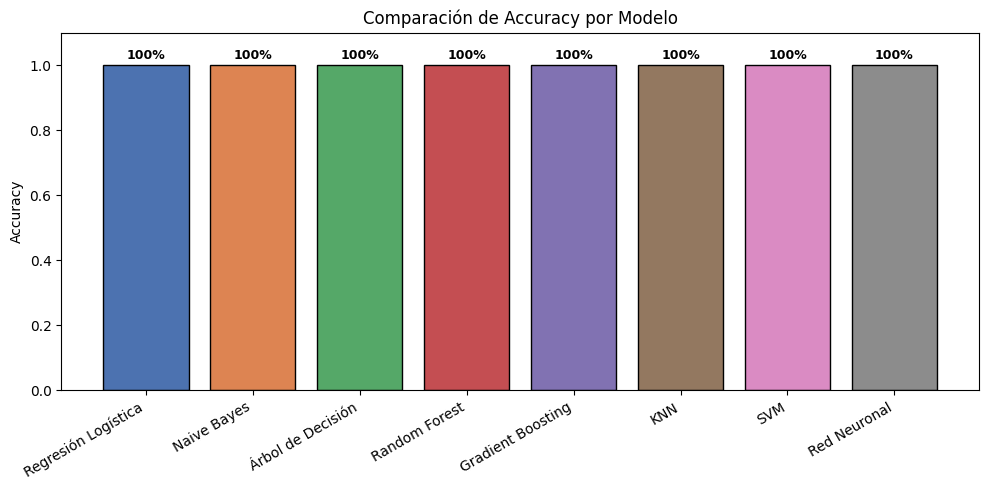


📊 Resultados:
  Regresión Logística      : 100.00%
  Naive Bayes              : 100.00%
  Árbol de Decisión        : 100.00%
  Random Forest            : 100.00%
  Gradient Boosting        : 100.00%
  KNN                      : 100.00%
  SVM                      : 100.00%
  Red Neuronal             : 100.00%


In [14]:
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

plt.figure(figsize=(10, 5))
bars = plt.bar(resultados.keys(), resultados.values(), color=colores, edgecolor='black')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Comparación de Accuracy por Modelo")

# Etiquetas encima de cada barra
for bar, val in zip(bars, resultados.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Resultados:")
for nombre, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    print(f"  {nombre:25s}: {acc:.2%}")

---
# 📌 Conclusiones

## ¿Qué aprendimos?

Hemos visto **8 modelos diferentes** aplicados al mismo problema. Todos logran resultados excelentes en Iris porque es un dataset bien estructurado, pero en problemas reales los resultados varían.

## 🗺️ Guía rápida para elegir modelo

| Modelo | Fortaleza | Úsalo cuando... |
|---|---|---|
| **Regresión Logística** | Simple, interpretable | Necesitas explicar el modelo o es un problema lineal |
| **Naive Bayes** | Rapidísimo | Tienes muchos datos y poco tiempo de cómputo |
| **Árbol de Decisión** | Transparente | Debes mostrar reglas claras al negocio |
| **Random Forest** | Robusto y preciso | Caso general, es un muy buen punto de partida |
| **Gradient Boosting** | Máxima precisión | Necesitas exprimir el máximo rendimiento |
| **KNN** | Simple, sin suposiciones | Datasets pequeños, exploración rápida |
| **SVM** | Bueno en espacios complejos | Pocas muestras pero muchas características |
| **Red Neuronal** | Muy flexible | Problemas complejos con muchos datos |

---

## 💡 Recuerda

> **No existe el mejor modelo universal.** La elección depende del tamaño del dataset, la necesidad de interpretabilidad, el tiempo de entrenamiento disponible y la complejidad del problema.

> Siempre empieza con modelos simples (Regresión Logística, Árbol) como **baseline** y aumenta complejidad solo si es necesario.
